In [1]:
from sklearn.manifold import Isomap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
#from sklearn.datasets.samples_generator import make_blobs
from sklearn.datasets import make_blobs

In [2]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


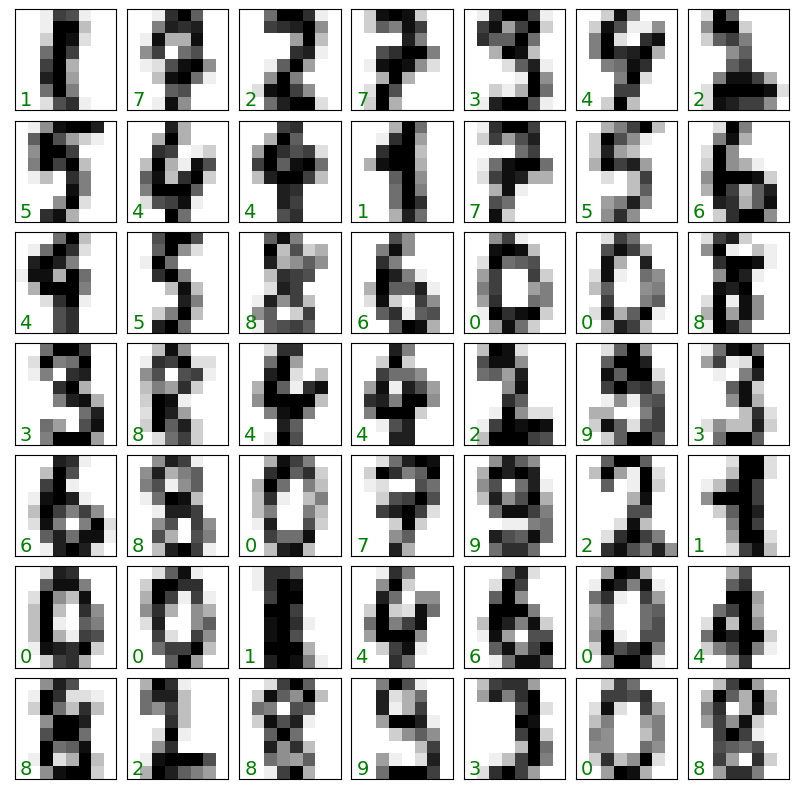

In [3]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [4]:
print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


In [5]:
data_digits = digits.data#[0]
digits.data.shape

X_train = data_digits 
digits.data.shape

(1797, 64)

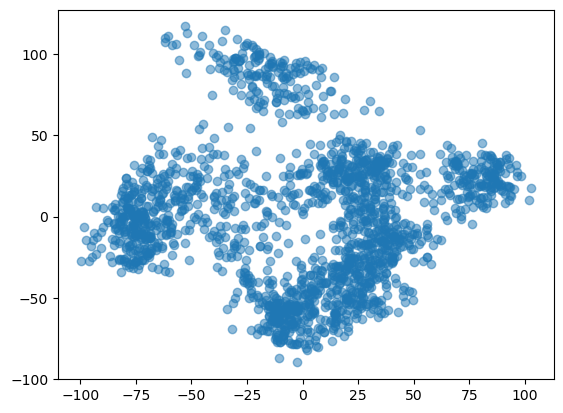

In [6]:
iso = Isomap(n_neighbors=15, n_components = 2)
iso.fit(X_train)
X_reduced =  iso.transform(X_train)


#visualize the result
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], alpha = 0.5)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
#splitting the dataset in training data and test dataset
Xtrain, Xtest ,Ytrain,Ytest= train_test_split(X_reduced, digits.target, test_size=0.2)

iso2 = Isomap(n_neighbors=15, n_components = 2)
iso2.fit(Xtrain)
Xtransformed = iso2.transform(Xtrain)

#define the model
model = LogisticRegression(solver = 'sag')

#definiing X and Y for fitting
#X = Xtransformed[:, 0].reshape(-1,1)
#Y = Xtransformed[:, 1]

#fit the "Xtrain" dataset with the model
model.fit(Xtransformed, Ytrain)

C:\Users\havef\OneDrive\Documents\conda\lib\site-packages\sklearn\linear_model\_sag.py:352: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(solver='sag')

In [8]:
#finding predictions for trained data and for test data
ypred = model.predict(Xtrain)
ypred_test = model.predict(Xtest)

In [9]:
#computing accurancy scores
acc_trained = accuracy_score(Ytrain, ypred,  normalize=True,)
acc_tested = accuracy_score(Ytest, ypred_test,  normalize=True,)
print(acc_trained, acc_tested)

0.6172581767571329 0.6055555555555555


In [10]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(Ytrain,ypred))

[[ 62   0   0   0   1   0  81   0   0   0]
 [ 13  77   8   0   3  10   2  26   6   2]
 [  0   0  84  55   0   0   0   1   5   4]
 [  4   0  12  71   0   0   0   0   1  54]
 [  0   3   0   0 141   0   0   3   0   0]
 [ 15  30   1   0   2  43  24  24   2   4]
 [  1   0   0   0   9   0 134   0   0   0]
 [  0   0  11   0   0   0   0 132   0   0]
 [  1   6  49  20   0   2   0   4  30  23]
 [  0   2   1   1   0   0   0  20   4 113]]


In [11]:
print(confusion_matrix(Ytest,ypred_test))

[[12  0  0  0  0  0 22  0  0  0]
 [ 3 21  2  0  0  2  2  3  1  1]
 [ 0  0 17  6  0  0  0  0  2  3]
 [ 3  0  5 13  0  0  0  1  1 18]
 [ 0  0  0  0 33  0  0  1  0  0]
 [ 4  9  0  0  2 13  5  1  0  3]
 [ 1  0  0  0  2  0 34  0  0  0]
 [ 0  0  2  0  0  0  0 34  0  0]
 [ 0  2 13  7  0  1  0  2 10  4]
 [ 0  1  0  0  0  0  0  6  1 31]]


array([0, 1, 2, ..., 8, 9, 8])